# Exercise 7

## Utils

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, exp, cos, sin, log
import random as rd

In [49]:
def dist(X,Y):
    return sqrt((X[0]-Y[0])**2 + (X[1]-Y[1])**2)

In [50]:
def plot_tsp_route(tour, points):
    """
    Plots the TSP route with arrows.
    
    Parameters:
    tour (list): Ordered list of indices representing the best tour (e.g., [0, 3, 1, 2])
    points (list or np.array): Coordinates of the cities/points, shape (n, 2)
    """
    points = np.array(points)
    n = len(tour)
    
    plt.figure(figsize=(6, 4))
    
    # 1. Plot the cities as scatter points
    plt.scatter(points[:, 0], points[:, 1], color='red', s=50, zorder=3, label='Cities')
    
    # Label each city with its index number
    for i, (x, y) in enumerate(points):
        plt.text(x + 0.05, y + 0.05, f"{i}", fontsize=8, weight='bold', color='blue')
        
    # 2. Draw the arrows connecting the tour
    for k in range(n):
        start_node = tour[k]
        # Use modulo (%) to loop back from the last city to the first city
        end_node = tour[(k + 1) % n] 
        
        x_start, y_start = points[start_node]
        x_end, y_end = points[end_node]
        
        # We use annotate to draw an arrow from start to end coordinates
        plt.annotate(
            '', # Leave text blank, we just want the arrow
            xy=(x_end, y_end),      # Where the arrow points to
            xytext=(x_start, y_start),  # Where the arrow starts
            arrowprops=dict(
                arrowstyle="->",    # Standard arrow shape
                color="black",      # Arrow line color
                lw=1.0,             # Line width
                ls="--",            # Dashed line style (optional)
                mutation_scale=15   # Changes arrow head size
            )
        )
        
    # Highlight the very first city in the tour so you know where it begins
    plt.scatter(points[tour[0]][0], points[tour[0]][1], color='green', s=100, zorder=4, label='Start/End')

    plt.title("Simulated Annealing: Best TSP Tour Route", fontsize=12)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

## Part 1 : TSP problem

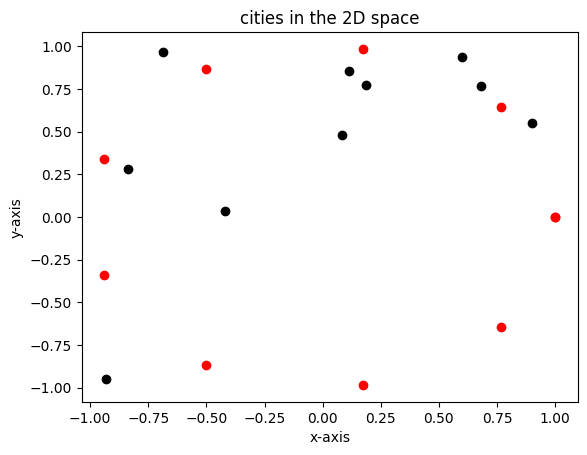

In [51]:
n = 10
# Generate n points
points = np.random.uniform(low = -1, high = 1, size=(n,2)) # random points
angles = np.linspace(0, 2*np.pi, n)
circular_points = np.array([[cos(angles[i]),sin(angles[i])] for i in range(n)]) # Points on a circle

plt.scatter(points[:,0],points[:,1],marker='o',c = 'black')
plt.scatter(circular_points[:,0],circular_points[:,1], marker = 'o', c = 'red')
plt.title("cities in the 2D space")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()
    

In [52]:
# Cost matrix
n = 10
Costs = np.array([[dist(points[i],points[j]) for j in range(n)] for i in range(n)])
circular_Costs = np.array([[dist(circular_points[i],circular_points[j]) for j in range(n)] for i in range(n)])

# Total cost of a tour -> what we want to minimize
def f(tour,n,Costs):
    S = 0
    for i in range(n-1):
        S+=Costs[tour[i],tour[i+1]]
    return S+Costs[tour[-1],tour[0]]


# Acceptance probability for Metropolis Hastings
def alpha(tour1, tour2, T,Costs):
    cost1 = f(tour1, n, Costs)
    cost2 = f(tour2, n, Costs)
    
    if cost2 <= cost1:
        return 1.0
    return exp((cost1 - cost2) / T)
# Proposal function 
def proposal(start,n):
    tour = start.copy()
    i = rd.randint(0,n-1)
    j = rd.randint(0,n-1)
    x = tour[j]
    tour[j]=tour[i]
    tour[i]=x
    return tour

def propose_segment_reversion(current_tour):
    
    n = len(current_tour)
    new_tour = np.array(current_tour).copy()
    
    # Pick two distinct random positions in the tour
    idx1, idx2 = np.random.choice(n, size=2, replace=False)
    
    # Ensure idx1 is the smaller index for slicing convenience
    start_idx = min(idx1, idx2)
    end_idx = max(idx1, idx2)
    
    # Reverse the segment
    # Case A: Standard contiguous segment inside the array
    if start_idx != 0 or end_idx != n - 1:
        new_tour[start_idx:end_idx+1] = new_tour[start_idx:end_idx+1][::-1]
        
    # Case B: Wrap-around segment (e.g., from the end of the array back to the front)
    else:
        # If the choice spans the absolute boundaries, we invert the outer loop paths.
        # Alternatively, we can just force standard internal inversions by shifting indices:
        # Re-rolling ensures we always get a valid internal inversion block
        while start_idx == 0 and end_idx == n - 1:
            idx1, idx2 = np.random.choice(n, size=2, replace=False)
            start_idx = min(idx1, idx2)
            end_idx = max(idx1, idx2)
        new_tour[start_idx:end_idx+1] = new_tour[start_idx:end_idx+1][::-1]
        
    return new_tour

# Generate a cooling schedule
def cooling_schedule(N_iterations, type = "sqrt", const = 1):
    if type == "sqrt" :
        return [const/sqrt(1+k) for k in range(N_iterations)]
    elif type == "ln" :
        return [const/log(2+k) for k in range(N_iterations)]

# Simulated annealing
def SA(start,Temperatures,n,N_iterations,Costs,display_alphas = False, prop = "switch"):
    f_min = f(start,n,Costs)
    tour_min = start
    for i in range(N_iterations):
        # print(f"Starting iteration {i}")
        if prop == "switch":
            tour = proposal(start,n)
        elif prop == "segment reversion":
            tour = propose_segment_reversion(start)
            
        cost = f(tour,n,Costs)
        a = alpha(start,tour,Temperatures[i],Costs)
        if display_alphas :
            print("alpha : ",a)
        u = rd.uniform(0,1)
        if u < a :
            if cost < f_min :
                f_min = cost
                tour_min = tour
            start = tour 
    return tour_min, f_min
            

In [53]:
N = 1000
n=10
start = [i for i in range(n)]
for i in range(100):
    start = proposal(start,n)
print(start)
Temp = cooling_schedule(N)
tour_min_circular, f_min_circular = SA(start,Temp,n,N,Costs = circular_Costs)
tour_min, f_min = SA(start,Temp,n,N,Costs = Costs)
print("Minimal tour for random points : ", tour_min)
print("Minimal tour for points on circle : ", tour_min_circular)

[2, 5, 1, 6, 7, 8, 0, 9, 3, 4]
Minimal tour for random points :  [7, 2, 6, 5, 0, 4, 9, 1, 8, 3]
Minimal tour for points on circle :  [3, 4, 5, 6, 7, 8, 0, 9, 1, 2]


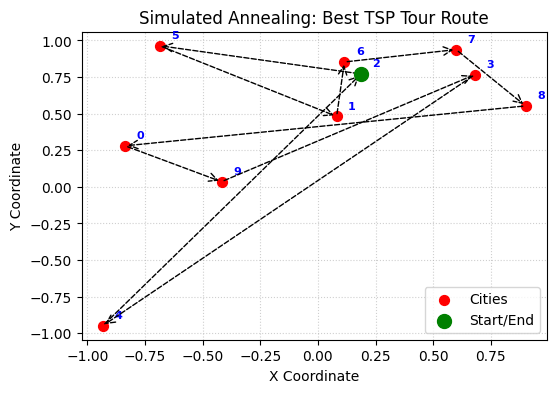

In [54]:
plot_tsp_route(start,points)

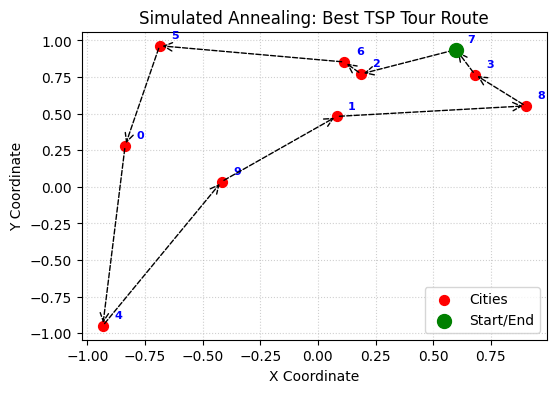

In [55]:
plot_tsp_route(tour_min,points)

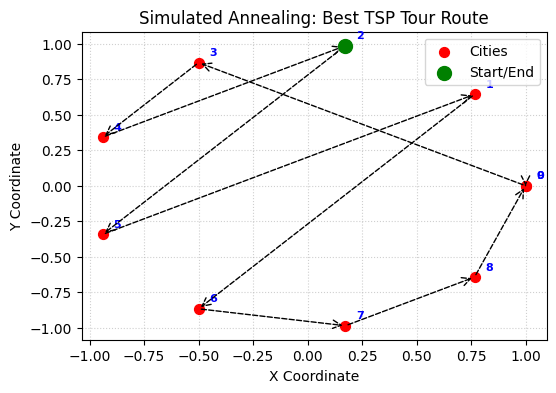

In [56]:
plot_tsp_route(start,circular_points)

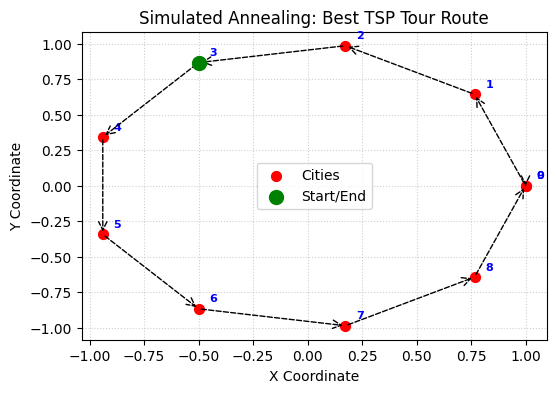

In [57]:
plot_tsp_route(tour_min_circular, circular_points)

## Part 2

We now use the general cost matrix imported from DTU Learn. We use a cooling schedule in the form $T_k = \frac{10000}{\sqrt(1+k)}$

In [58]:
# Load the general costs from Learn
C = np.loadtxt("cost.csv", delimiter=",")
n = len(C) # 20
N = 1000000
start = [i for i in range(n)]
for i in range(200):
    start = proposal(start,n)
Temp = cooling_schedule(N,type="sqrt", const = 10000)
tour_min, f_min = SA(start,Temp,n,N,Costs = C)
print("Best tour found : ", tour_min)
print("Total cost from the starting tour : ",f(start,n,C))
print("Total cost from the best tour found : ", f_min)

Best tour found :  [17, 16, 4, 7, 15, 9, 18, 14, 1, 8, 13, 11, 5, 0, 12, 3, 2, 10, 19, 6]
Total cost from the starting tour :  2939.0
Total cost from the best tour found :  786.0


Now the cooling schedule becomes $T_k = \frac{10000}{\ln(2+k)}$

In [59]:
n = len(C) # 20
N = 1000000
start = [i for i in range(n)]
for i in range(200):
    start = proposal(start,n)
Temp = cooling_schedule(N,type="ln", const = 10000)
tour_min, f_min = SA(start,Temp,n,N,Costs = C)
print("Best tour found : ", tour_min)
print("Total cost from the starting tour : ",f(start,n,C))
print("Total cost from the best tour found : ", f_min)

Best tour found :  [19, 12, 0, 18, 14, 13, 1, 15, 9, 7, 4, 8, 5, 11, 3, 2, 10, 17, 6, 16]
Total cost from the starting tour :  3614.0
Total cost from the best tour found :  1062.0


Let's try again we the former square root schedule : $T_k = \frac{10000}{\sqrt(1+k)}$ and a new proposal method : from the current tour $[t_1, t_2, ..., t_n]$, we sample a random segment $[t_i,t_{i+1},...,t_{j-1},t_j]$ and revert it  $[t_j,t_{j-1},...,t_{i+1},t_i]$. The new tour containing the reverted segment stands for the new proposal.

In [60]:
n = len(C) # 20
N = 1000000
start = [i for i in range(n)]
for i in range(200):
    start = proposal(start,n)
Temp = cooling_schedule(N,type="sqrt", const = 10000)
tour_min, f_min = SA(start,Temp,n,N,Costs = C,prop = "segment reversion") # The proposal function takes a random segment inside the tour and reverses it 
print("Best tour found : ", tour_min)
print("Total cost from the starting tour : ",f(start,n,C))
print("Total cost from the best tour found : ", f_min)

Best tour found :  [ 8 13 11  5  0 12  3  2 10 19  6 17 16  4  7 15  9 18 14  1]
Total cost from the starting tour :  3524.0
Total cost from the best tour found :  786.0
